## Refinement based on pure reweighting
to see the advantages of on-the-fly refinement

In [1]:
import os, pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')

from simpleMD import SimpleMD  # required to load pickles
from my_tools import compute_SAXS

In [3]:
from MDRefine import load_data, minimizer

### 1. prepare data 
from `SimpleMD` outputs (in `data` directory) to `MDRefine` (new directory `polymer`)

In [4]:
with open("../data/prior.pkl", "rb") as file:
    smd_prior = pickle.load(file)


In [5]:
vars(smd_prior).keys()

dict_keys(['iv', 'iy', 'iset', 'gset', 'write_positions_first', 'write_statistics_first', 'write_statistics_last_time_reopened', 'write_statistics_fp', 'temperature', 'maxneighbors', 'tstep', 'friction', 'forcecutoff', 'k_fene', 'maxbond', 'k_angle', 'l_rgyr2', 'exp_rgyr2', 'k_rgyr2', 'tau_rgyr2', 'alpha_rgyr2', 'sigma_rgyr2', 'q_SAXS', 'l_SAXS', 'a_SAXS', 'b_SAXS', 'c_SAXS', 'exp_SAXS', 'k_SAXS', 'tau_SAXS', 'alpha_SAXS', 'sigma_SAXS', 'k_fm', 'tau_fm', 'listcutoff', 'nstep', 'nconfig', 'nstat', 'nequilib', 'nonthefly', 'idum', 'wrapatoms', 'statfile', 'trajfile', 'outputfile', 'inputfile', 'positions', 'cell', 'statfile_f', 'statistics', 'lambda_otf', 'SAXS_otf', 'fm_otf', 'trajectory', 'SAXS', 'grad_lambda', 'angle', 'output'])

#### `forward_qs`
quantities required to compute the observables by evaluation of the `forward_model_fun` function
- in this case, SAXS values for each frame of the trajectory, since the correction to the forward model is a linear combination of them (for each frame)

In [6]:
traj = np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))])

print('shape of traj: ', traj.shape)

shape of traj:  (10100, 10, 3)


In [7]:
smd_prior.angle[5].shape

(101000,)

they have different number of frames!!??

In [8]:
cell = (100., 100., 100.)

saxs = []

for i in range(len(traj)):
    saxs.append(compute_SAXS(traj[i], cell, smd_prior.q_SAXS))

saxs = np.array(saxs)

In [9]:
!mkdir ../data_MDRefine
!mkdir ../data_MDRefine/polymer
!mkdir ../data_MDRefine/polymer/forward_qs

if not 'saxs.npy' in os.listdir('../data_MDRefine/polymer/forward_qs'):
    np.save('../data_MDRefine/polymer/forward_qs/saxs.npy', saxs)

In [10]:
lines = ["A,1", "B,0"]

with open("../data_MDRefine/original_fm_coeffs", "w") as f:
    for line in lines:
        f.write(line + "\n")

#### experimental values

In [11]:
with open("../data/test.pkl", "rb") as file:
    smd_reference = pickle.load(file)

In [13]:
exp_saxs = 1.5*smd_reference.SAXS + 2.0
sigma_saxs = 1.0*np.ones(len(exp_saxs))

exp_vals = np.vstack((exp_saxs, sigma_saxs)).T

!mkdir ../data_MDRefine/polymer/g_exp
np.save('../data_MDRefine/polymer/g_exp/saxs.npy', exp_vals)

In [14]:
!mkdir ../data_MDRefine/polymer/names
np.save('../data_MDRefine/polymer/names/saxs.npy', np.array(smd_reference.q_SAXS).T)

In [15]:
assert (smd_reference.q_SAXS == smd_prior.q_SAXS), 'error: mismatch on q_SAXS'

### 2. load data

In [16]:
infos = {'global': {
    'path_directory': '../data_MDRefine',
    'system_names': ['polymer'],
    'g_exp': ['saxs'],
    'forward_qs': ['saxs'],
    'forward_coeffs': 'original_fm_coeffs'  # np.array([1., 0.])
}}

In [17]:
def forward_model_fun(fm_coeffs, forward_qs, selected_obs = None):
    forward_qs_out = {'saxs': fm_coeffs[0]*forward_qs['saxs'] + fm_coeffs[1]}
    return forward_qs_out

infos['global']['forward_model'] = forward_model_fun

In [18]:
data = load_data(infos)

loading data from directory...
loading  polymer
done


In [22]:
vars(data.mol['polymer']).keys()

dict_keys(['temperature', 'gexp', 'names', 'ref', 'forward_model', 'forward_qs', 'weights', 'g', 'n_experiments', 'n_frames'])

In [23]:
def forward_model_regularization(coeffs, coeffs0):
    regularization = jnp.log(coeffs[0])
    return regularization

regularization = {'forward_model_reg' : forward_model_regularization}

### 2. minimize the loss function
purely based on reweighting initial trajectory

In [24]:
result = minimizer(data, regularization=regularization, alpha=1, gamma=1, if_print_biblio=False)

In [25]:
vars(result)

{'loss': Array(4.49219424, dtype=float64),
 'pars': array([  1.85569695, -13.84883942]),
 'mini':   message: Optimization terminated successfully.
   success: True
    status: 0
       fun: 4.492194237222023
         x: [ 1.856e+00 -1.385e+01]
       nit: 14
       jac: [-7.575e-04 -9.334e-05]
  hess_inv: [[ 3.735e-02 -1.663e+00]
             [-1.663e+00  7.459e+01]]
      nfev: 15
      njev: 15,
 'min_lambdas': {'polymer': {'saxs': Array([ 0.09323272, -0.05743747, -0.19123512, -0.20447685, -0.05707175,
           0.19534716,  0.41098027,  0.41529586,  0.07040328, -0.67513145],      dtype=float64)}},
 'minis': {'polymer':   message: Optimization terminated successfully.
    success: True
     status: 0
        fun: -3.8739338999442094
          x: [ 5.364e-03 -1.284e-02 -9.182e-02 -1.638e-01 -6.603e-02
               2.967e-01  7.646e-01  8.972e-01  1.691e-01 -1.737e+00]
        nit: 6
        jac: [-2.432e-04 -2.144e-04  1.724e-04  2.830e-04 -2.891e-04
              -3.033e-04 -8.650

In [27]:
new_weights = result.weights_new['polymer']

print(len(new_weights), len(smd_prior.angle[5]))

10100 101000


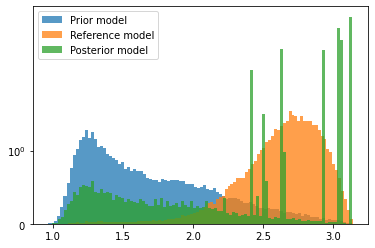

In [28]:
plt.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_reference.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
plt.hist(smd_prior.angle[5][::10], weights=new_weights, bins=100, density=True, alpha=0.75, label='Posterior model')

plt.yscale('symlog')
plt.legend()